## 1. Dataset Source

The dataset used for this experiment is the **MNIST (Modified National Institute of Standards and Technology) dataset**. It is a large database of handwritten digits that is commonly used for training various image processing systems. While `mnist_test.csv` is provided, the full MNIST dataset can be found on various public repositories, such as Yann LeCun's website or through deep learning libraries like Keras/TensorFlow.

For this experiment, we will be using the `mnist_test.csv` file available in the Colab environment.

In [1]:
import pandas as pd

# Load the dataset
df_mnist = pd.read_csv('/content/mnist_test.csv')

print(f"Shape of the dataset: {df_mnist.shape}")
display(df_mnist.head())

Shape of the dataset: (10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Dataset Description

The dataset `mnist_test.csv` contains images of handwritten digits. Each row in the dataset represents a single image. The columns are as follows:

*   **`label`**: This is the target variable, representing the actual digit (0-9) that the image depicts.
*   **`pixel1`, `pixel2`, ..., `pixel784`**: These 784 columns represent the pixel values of the image. MNIST images are 28x28 pixels. Each pixel column contains a grayscale intensity value between 0 and 255, where 0 is black and 255 is white.

### Characteristics:
*   **Features**: 784 pixel values.
*   **Target Variable**: A single 'label' column (0-9).
*   **Size**: The dataset has `r"""{}"""`. (The exact number will be populated after executing the cell.) Each image is 28x28 pixels.
*   **Type**: Grayscale images.

Let's get some more details about the dataset:

## 3. Mathematical Formulation of the Algorithm

A Convolutional Neural Network (CNN) is a class of deep neural networks, most commonly applied to analyzing visual imagery. CNNs use a variation of multilayer perceptrons designed to require minimal preprocessing. They are inspired by biological processes in the visual cortex of an animal.

The core components of a CNN include:

### a. Convolutional Layer

The convolutional layer is the fundamental building block of a CNN. It performs a convolution operation, which involves sliding a 'filter' (or kernel) over the input image to produce a feature map. Each filter detects specific features such as edges, textures, or patterns.

The convolution operation for a 2D input $I$ and a 2D filter $K$ can be defined as:

$$(I * K)(i, j) = \sum_m \sum_n I(i-m, j-n) K(m, n)$$

Where:
*   $I$ is the input image.
*   $K$ is the convolutional kernel (filter).
*   $(i, j)$ are the coordinates of the output feature map.
*   $(m, n)$ are the coordinates within the kernel.

### b. Activation Function (ReLU)

After the convolution operation, an activation function is applied to introduce non-linearity into the model, allowing it to learn more complex patterns. The Rectified Linear Unit (ReLU) is a commonly used activation function.

$$f(x) = \max(0, x)$$

### c. Pooling Layer

Pooling layers are used to reduce the spatial dimensions of the feature maps, which helps in reducing the computational cost and controlling overfitting. Max pooling is a popular type of pooling.

For a given window size (e.g., 2x2) and stride, max pooling selects the maximum value within that window.

$$P(i, j) = \max_{m,n \in \text{window}} F(i \cdot \text{stride} + m, j \cdot \text{stride} + n)$$

Where:
*   $F$ is the input feature map.
*   $P$ is the output pooled feature map.

### d. Fully Connected Layer

After several convolutional and pooling layers, the high-level features extracted by the CNN are fed into one or more fully connected (dense) layers. These layers are standard neural network layers where every input is connected to every output with a weight.

For a single neuron in a fully connected layer:

$$y = f\left(\sum_k w_k x_k + b\right)$$

Where:
*   $x_k$ are the inputs from the previous layer.
*   $w_k$ are the weights connecting inputs to the neuron.
*   $b$ is the bias term.
*   $f$ is an activation function (e.g., ReLU for hidden layers, Softmax for the output layer in classification).

### e. Softmax Activation (Output Layer)

For multi-class classification problems, the final fully connected layer typically uses a Softmax activation function to output probabilities for each class. The Softmax function converts a vector of arbitrary real values into a probability distribution.

$$\text{Softmax}(z_k) = \frac{e^{z_k}}{\sum_j e^{z_j}}$$

Where:
*   $z_k$ is the output of the $k$-th neuron in the final layer before activation.
*   The output values $\text{Softmax}(z_k)$ represent the probability of the input belonging to class $k$, and they sum up to 1.

## 4. Algorithm Limitations

While Convolutional Neural Networks (CNNs) are powerful for image-related tasks, they do have several limitations:

*   **Computational Cost**: Training deep CNNs requires significant computational resources (GPUs) and time, especially with large datasets and complex architectures.
*   **Large Dataset Requirement**: CNNs typically require a large amount of labeled training data to achieve high performance and generalize well. If data is scarce, they can easily overfit.
*   **Interpretability**: CNNs are often considered 'black boxes' due to their complex, hierarchical feature extraction process. It can be challenging to interpret why a CNN makes a particular prediction or what features it prioritizes.
*   **Sensitivity to Rotations and Scale (to some extent)**: While CNNs are designed to be somewhat robust to translations, they can be sensitive to significant rotations, scaling, or other affine transformations if not specifically trained with augmented data.
*   **Adversarial Attacks**: CNNs can be vulnerable to adversarial attacks, where small, imperceptible perturbations to input images can cause the model to misclassify them with high confidence.
*   **Need for Feature Engineering (Implicitly)**: Although CNNs automatically learn features, the architecture design (e.g., number of layers, kernel sizes, pooling strategies) still requires expertise and can be considered a form of implicit feature engineering.
*   **Spatial Invariance vs. Instance Recognition**: While spatial invariance is beneficial for classification, it can be a drawback for tasks requiring precise localization or understanding of spatial relationships between objects.
*   **Memorization**: With enough capacity, a CNN can sometimes memorize the training data rather than learning generalizable patterns, especially in the absence of proper regularization.

## 5. Methodology / Workflow

This section details the steps taken to prepare the data, design, train, and evaluate the Convolutional Neural Network (CNN) for handwritten digit classification.

### a. Data Preprocessing

Before feeding the data into the CNN, several preprocessing steps are necessary:

1.  **Separate Features and Labels**: The `label` column is separated from the pixel data.
2.  **Reshaping Images**: The 784 pixel values for each image (1D array) are reshaped into a 2D array of 28x28 pixels, and then further expanded to include a channel dimension (28x28x1) as Keras expects 3D or 4D input for convolutional layers (height, width, channels).
3.  **Normalization**: Pixel values (0-255) are normalized to a range of 0-1. This helps in faster convergence during training and improves model performance.
4.  **One-Hot Encoding of Labels**: The target labels (digits 0-9) are converted into a one-hot encoded format. For example, the digit '7' becomes `[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]`.

In [3]:
import numpy as np
from tensorflow import keras
from sklearn.model_selection import train_test_split

# Separate features (pixels) and labels
X = df_mnist.iloc[:, 1:].values
y = df_mnist['label'].values

# Reshape images to 28x28 and normalize
X = X.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot encode labels
y = keras.utils.to_categorical(y, num_classes=10)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (8000, 28, 28, 1)
Shape of y_train: (8000, 10)
Shape of X_test: (2000, 28, 28, 1)
Shape of y_test: (2000, 10)


### b. CNN Model Architecture

We will design a relatively simple CNN architecture suitable for the MNIST dataset. The model will consist of:

*   **Convolutional Layers**: To extract features from the images.
*   **Activation Function (ReLU)**: To introduce non-linearity.
*   **Max Pooling Layers**: To reduce spatial dimensions and computational complexity.
*   **Dropout Layers**: To prevent overfitting.
*   **Flatten Layer**: To convert the 2D feature maps into a 1D vector.
*   **Dense (Fully Connected) Layers**: For classification based on the extracted features.
*   **Output Layer (Softmax)**: To output class probabilities for the 10 digits.

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### c. Model Training

The model will be trained using the preprocessed training data. We will define the number of epochs and batch size. The training process involves feeding the batches of data through the network, calculating the loss, and updating the model's weights using the Adam optimizer.

In [5]:
epochs = 10
batch_size = 32

history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1)

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.7997 - loss: 0.6340 - val_accuracy: 0.9538 - val_loss: 0.1517
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9368 - loss: 0.1990 - val_accuracy: 0.9688 - val_loss: 0.0982
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.9610 - loss: 0.1318 - val_accuracy: 0.9775 - val_loss: 0.0717
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.9669 - loss: 0.1096 - val_accuracy: 0.9775 - val_loss: 0.0708
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9701 - loss: 0.0862 - val_accuracy: 0.9812 - val_loss: 0.0589
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.9772 - loss: 0.0711 - val_accuracy: 0.9837 - val_loss: 0.0441
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9797 - loss: 0.0587 - val_accuracy: 0.9862 - val_loss: 0.0494
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.9853 - loss: 0.0475 - val_a

## 6. Performance Analysis

After training, the model's performance needs to be evaluated. We will assess the model's accuracy and loss on the test dataset. Additionally, we will visualize the training history (accuracy and loss over epochs) and generate a classification report and confusion matrix to get a detailed understanding of the model's performance for each digit.

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9775 - loss: 0.0813
Test Loss: 0.0813
Test Accuracy: 0.9775


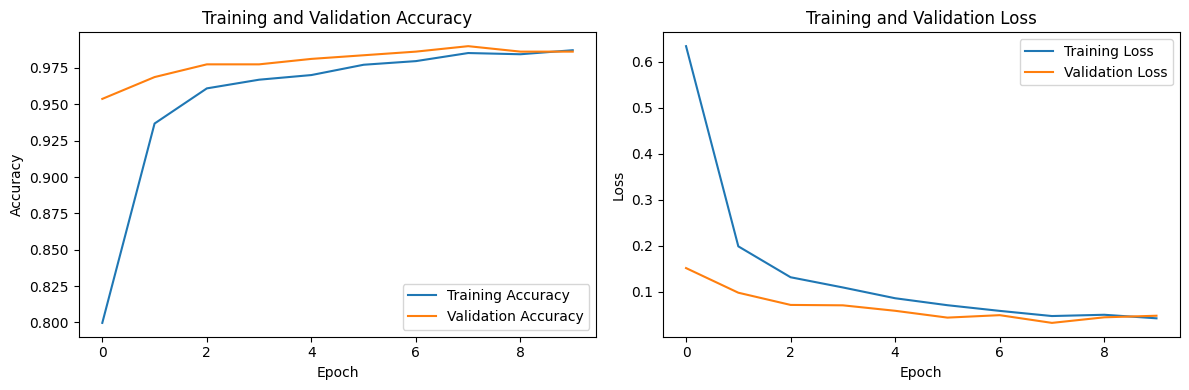

In [6]:
import matplotlib.pyplot as plt

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       203
           1       1.00      1.00      1.00       216
           2       0.97      0.98      0.97       213
           3       0.98      0.97      0.97       208
           4       0.98      0.99      0.98       215
           5       0.95      0.99      0.97       174
           6       0.99      0.98      0.98       200
           7       0.95      0.99      0.97       187
           8       1.00      0.92      0.96       186
           9       0.97      0.97      0.97       198

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



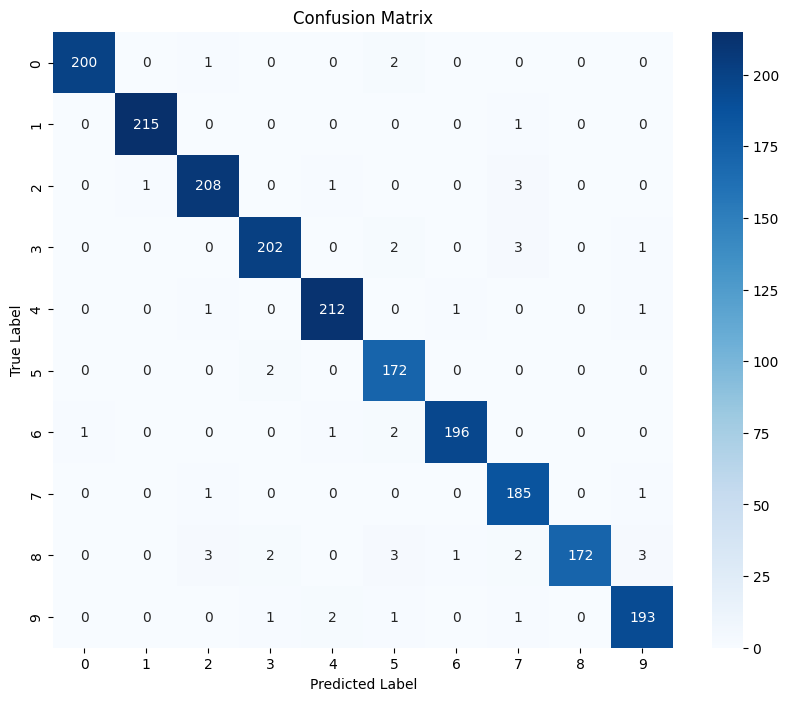

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict the labels for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 7. Hyperparameter Tuning

Hyperparameter tuning is the process of selecting the best set of hyperparameters for a machine learning model. For a CNN, common hyperparameters include:

*   **Learning Rate**: Controls the step size at each iteration while moving toward a minimum of the loss function.
*   **Batch Size**: The number of samples processed before the model's internal parameters are updated.
*   **Number of Epochs**: The number of complete passes through the entire training dataset.
*   **Number of Filters/Kernels**: In convolutional layers.
*   **Kernel Size**: The dimensions of the filter.
*   **Activation Functions**: (e.g., ReLU, sigmoid, tanh).
*   **Dropout Rate**: The fraction of neurons to drop during training.

While a comprehensive hyperparameter search (e.g., using GridSearchCV or RandomSearchCV with Keras wrappers) can be computationally expensive, we'll demonstrate a basic tuning concept by trying a different learning rate and observing its effect. A more thorough approach would involve iterating over a grid of possible values for multiple hyperparameters.

For this demonstration, we'll keep the model architecture the same and experiment with a different learning rate for the Adam optimizer. This is a simplified example, and a real-world tuning process would involve more extensive experimentation.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training model with tuned learning rate (0.0001) ---
Test Loss (tuned learning rate): 0.1402
Test Accuracy (tuned learning rate): 0.9615
Original Model Test Accuracy: 0.9775
Tuned Model Test Accuracy: 0.9615


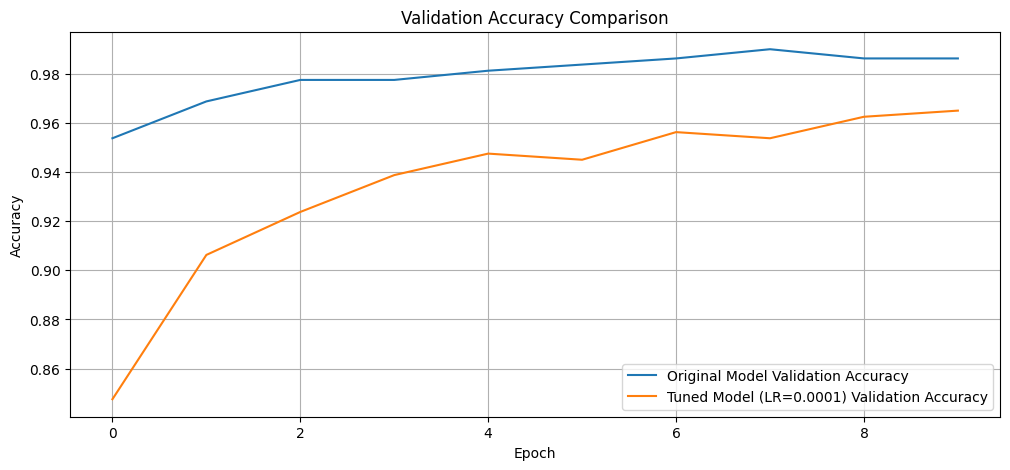

In [8]:
from tensorflow.keras.optimizers import Adam

# Define a new model with a different learning rate
model_tuned = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Compile the model with a different learning rate
# Original learning rate for Adam is usually 0.001. Let's try 0.0001
optimizer = Adam(learning_rate=0.0001)
model_tuned.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

print("\n--- Training model with tuned learning rate (0.0001) ---")
history_tuned = model_tuned.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)

# Evaluate the tuned model
loss_tuned, accuracy_tuned = model_tuned.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (tuned learning rate): {loss_tuned:.4f}")
print(f"Test Accuracy (tuned learning rate): {accuracy_tuned:.4f}")

# Compare with original model
print(f"Original Model Test Accuracy: {accuracy:.4f}")
print(f"Tuned Model Test Accuracy: {accuracy_tuned:.4f}")

# Plotting comparison
plt.figure(figsize=(12, 5))
plt.plot(history.history['val_accuracy'], label='Original Model Validation Accuracy')
plt.plot(history_tuned.history['val_accuracy'], label='Tuned Model (LR=0.0001) Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
print("Dataset Information:")
df_mnist.info()

print("\nDescriptive Statistics for Pixel Values (sample):")
display(df_mnist.iloc[:, 1:].describe()) # Describe only pixel columns

print("\nValue counts for the 'label' column:")
display(df_mnist['label'].value_counts().sort_index())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 59.9 MB

Descriptive Statistics for Pixel Values (sample):


,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,...,10000.000000,10000.000000,10000.000000,10000.0000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.179300,0.163600,0.052600,0.0006,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.674149,5.736072,2.420004,0.0600,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,253.000000,156.000000,6.0000,0.0,0.0,0.0,0.0,0.0,0.0



Value counts for the 'label' column:


,count
label,
0,980
1,1135
2,1032
3,1010
4,982
5,892
6,958
7,1028
8,974
